# LASSO vs. Losgistic Regression in Classification



## 1. Logistic Regression Decision Boundary

[None, (-5.0, 5.0), (-5.0, 5.0), Text(0.5, 0, '$X_1$'), Text(0, 0.5, '$X_2$')]

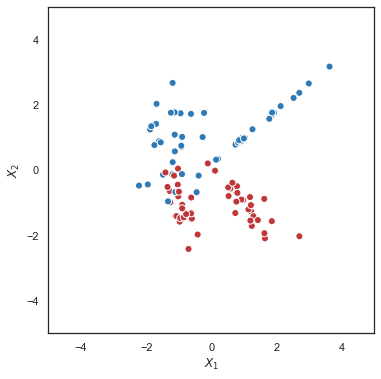

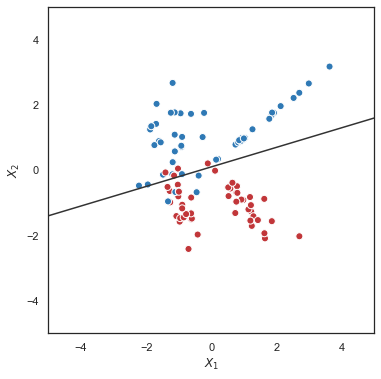

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white")

X, y = make_classification(200, 2, 2, 0, weights=[.5, .5], random_state=15)
clf = LogisticRegression().fit(X[:100], y[:100])

xx, yy = np.mgrid[-5:5:.01, -5:5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white")

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")

f, ax = plt.subplots(figsize=(8, 6))
ax.contour(xx, yy, probs, levels=[.5], cmap="Greys", vmin=0, vmax=.6)

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")

## 2. LASSO

Just like in the regression case, LASSO shrinks small coefficients to zeros.  Change alpha to see its effect on the decision boundary. 

[None, (-5.0, 5.0), (-5.0, 5.0), Text(0.5, 0, '$X_1$'), Text(0, 0.5, '$X_2$')]

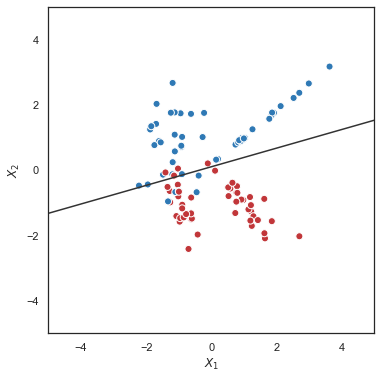

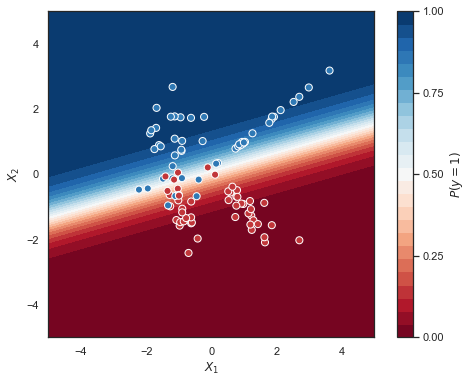

In [8]:
alpha= .01

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier

X, y = make_classification(200, 2, 2, 0, weights=[.5, .5], random_state=15)

clf = SGDClassifier(loss='log', penalty='elasticnet', alpha=alpha, l1_ratio=1)
clf.fit(X[:100], y[:100])

xx, yy = np.mgrid[-5:5:.01, -5:5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 6))
ax.contour(xx, yy, probs, levels=[.5], cmap="Greys", vmin=0, vmax=.6)

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")

## 3. On Titanic Dataset

#### a. Logistic Regression

In [59]:
import pandas as pd
import numpy as np
np.random.seed(12356)
df = pd.read_csv('titanic.csv')
# Assign input variables
X = df.loc[:,['Pclass','Sex','Age','Fare','Embarked','SibSp','Parch']]

# Assign target variable
y = df['Survived']

# Replace missing values by the median
X["Age"] = X["Age"].fillna(X["Age"].median())

# Impute the Embarked variable
X["Embarked"] = X["Embarked"].fillna("S")
# Change Pclass to categorical variable
X['Pclass'] = X['Pclass'].astype(object)

# Encode categorical variable
X = pd.get_dummies(X)

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)
# Accuracry on test data
print("Logistic Regression's Testing Accuracy: ", model.score(x_test, y_test))

coef1 = pd.DataFrame({'Variable':x_train.columns, 
                     'Coef':model.coef_.reshape(x_train.columns.shape[0],),
                      'Model': 'Logistic Regression',
                      'Data': 'Original'
                    })

Logistic Regression's Testing Accuracy:  0.8246268656716418


#### b. LASSO

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white")
model = SGDClassifier(loss='log', penalty='elasticnet', alpha=.01, l1_ratio=1)
model.fit(x_train, y_train)

print("LASSO's Testing Accuracy: ", model.score(x_test, y_test))

coef2 = pd.DataFrame({'Variable':x_train.columns, 
                     'Coef':model.coef_.reshape(x_train.columns.shape[0],),
                      'Model': 'Logistic Regression',
                      'Data': 'Original'
                    })

LASSO's Testing Accuracy:  0.8208955223880597


#### c. Coefficients

In [61]:
coef = pd.concat([coef1, coef2], ignore_index=True, axis=1)
coef = coef.drop([2, 3, 4, 6, 7], axis=1)
coef.columns = ['Variable','Linear Model', 'LASSO']
coef

,Variable,Linear Model,LASSO
0,Age,-0.043032,0.000000
1,Fare,0.000914,0.000000
2,SibSp,-0.237338,-11.571108
3,Parch,-0.005294,-0.605553
4,Pclass_1,1.223241,0.317011
5,Pclass_2,0.299305,3.920123
6,Pclass_3,-0.947509,-6.277223
7,Sex_female,1.522144,19.010180
8,Sex_male,-0.947108,-14.650845
9,Embarked_C,0.187487,0.000000


## 4. Practice

A. Use the breast cancer dataset ([link](https://bryantstats.github.io/math460/breast_cancer.csv))

 - Split the data 80:20 for training and testing
 - Calculate the testing Accuracy of linear model and show the coefficients of the models
 - Calculate the testing Accuracy of LASSO model with alpha = 1. Show the coefficients of the LASSO. Do you observe any variables no longer has effect in the LASSO model?
 - Change the value of alpha in the LASSO and observe the Accuracy of LASSO. Give your comments.
 - Plot the coefficients of linear model and LASSO.

B. Redo part A on a different dataset.

